Data Loading & Inspection


In [141]:
import pandas as pd
import numpy as np
# Load CSVs
customers = pd.read_csv('data/raw/customers.csv')
sessions  = pd.read_csv('data/raw/sessions.csv')
orders    = pd.read_csv('data/raw/orders.csv')

# Dataframe Shape check 
print("TABLE SHAPES")
for name, df in [('customers', customers), ('sessions', sessions), ('orders', orders)]:
    print(f"  {name:12s} → {df.shape[0]:,} rows  ×  {df.shape[1]} columns")

#  dtypes inspection
for name, df in [('CUSTOMERS', customers), ('SESSIONS', sessions), ('ORDERS', orders)]:
    print(f"\n DTYPES — {name}")
    display(df.dtypes.to_frame(name='dtype'))


TABLE SHAPES
  customers    → 5,050 rows  ×  7 columns
  sessions     → 30,150 rows  ×  7 columns
  orders       → 12,100 rows  ×  10 columns

 DTYPES — CUSTOMERS


,dtype
customer_id,int64
signup_date,object
acquisition_channel,object
device_type,object
age_group,object
country,object
is_premium,object



 DTYPES — SESSIONS


,dtype
session_id,int64
customer_id,int64
session_date,object
session_duration_min,float64
pages_viewed,float64
funnel_stage_reached,object
utm_source,object



 DTYPES — ORDERS


,dtype
order_id,int64
customer_id,int64
order_date,object
product_category,object
quantity,int64
unit_price,float64
discount_pct,float64
total_revenue,float64
payment_method,object
order_status,object


In [142]:
# Converitng 'customer_id','session_id','customer_id' int64 to object type

# Customers
customers['customer_id'] = customers['customer_id'].astype(str)

# Sessions
sessions['session_id']  = sessions['session_id'].astype(str)
sessions['customer_id'] = sessions['customer_id'].astype(str)

# Orders
orders['order_id']    = orders['order_id'].astype(str)
orders['customer_id'] = orders['customer_id'].astype(str)

# Verify
print(orders[['order_id', 'customer_id']].dtypes)
print(customers['customer_id'].dtype)
print(sessions[['session_id', 'customer_id']].dtypes)

#  Showing head for all dataframe
for name, df in [('CUSTOMERS', customers), ('SESSIONS', sessions), ('ORDERS', orders)]:
    print(f"\n HEAD — {name}")
    display(df.head(5))

order_id       object
customer_id    object
dtype: object
object
session_id     object
customer_id    object
dtype: object

 HEAD — CUSTOMERS


,customer_id,signup_date,acquisition_channel,device_type,age_group,country,is_premium
0,1001,2022-08-17,paid_search,mobile,25-34,US,False
1,1002,2022-02-21,referral,mobile,25-34,UK,True
2,1003,2023-07-18,social,desktop,25-34,UK,False
3,1004,2023-05-17,social,mobile,35-44,DE,False
4,1005,2023-04-03,organic,desktop,35-44,DE,False



 HEAD — SESSIONS


,session_id,customer_id,session_date,session_duration_min,pages_viewed,funnel_stage_reached,utm_source
0,90001,4190,2022-08-17 07:55:00,2.89,3.0,visited,email
1,90002,1565,2022-02-21 08:03:00,22.66,16.0,purchased,paid_search
2,90003,1446,2023-07-18 17:57:00,2.47,3.0,visited,referral
3,90004,5591,2023-05-17 12:35:00,17.77,14.0,checkout,social
4,90005,1949,2023-04-03 16:08:00,25.91,17.0,purchased,email



 HEAD — ORDERS


,order_id,customer_id,order_date,product_category,quantity,unit_price,discount_pct,total_revenue,payment_method,order_status
0,50001,2890,2022-08-17,Home,1,278.33,17.1,230.74,card,returned
1,50002,3310,2022-02-21,Beauty,1,72.29,7.5,66.87,card,completed
2,50003,5257,2023-07-18,Sports,1,32.19,9.4,29.16,paypal,completed
3,50004,2639,2023-05-17,Clothing,1,118.76,2.0,116.38,card,cancelled
4,50005,5326,2023-04-03,Sports,2,170.82,20.5,271.60,paypal,completed


Data quality assesment for customers table and cleaning.

In [143]:
customers.describe(include='all')

,customer_id,signup_date,acquisition_channel,device_type,age_group,country,is_premium
count,5050,5050,4799,4799,4799,4799,4799
unique,5000,1088,5,3,5,5,3
top,2978,99-99-9999,organic,mobile,25-34,DE,False
freq,2,20,1472,2727,1463,1361,3862


#### Diagnosis of Customers Table

**1.** `customer_id` column has 50 duplicate entries.

**2.** `is_premium` column contains 251 `NaN` values. Additionally, 30 rows have the value `"yes"` which is logically incorrect — this is a boolean column and should only contain `True` or `False`.

**3.** `signup_date` has 20 rows with invalid date formats such as `"99-99-9999"`.

**4.** `acquisition_channel`, `device_type`, `age_group`, and `country` columns each contain 249 `NaN` values.

---

#### Pre-processing and Cleaning Steps

**1.** Dropped duplicate entries from `customer_id`.

**2.** Replaced `"yes"` with `False` in `is_premium` column and handled `NaN` values accordingly.

**3.** Replaced invalid date entries `"99-99-9999"` with `NaN` in `signup_date` column, dropped the `NaN` rows, and parsed the column to `datetime`.

**4.** Dropped rows where critical columns `customer_id` and `signup_date` were `NaN`.

**5.** Filled `NaN` values in categorical columns `acquisition_channel`, `device_type`, `age_group`, and `country` with `"unknown"`.



In [144]:
#Checking duplicate of customers table for customer_id column 
print("Total duplicate rows found:",customers['customer_id'].duplicated().sum()) 
# Drop duplicates based on customer_id, keep first occurrence
customers = customers.drop_duplicates(subset=['customer_id'], keep='first')
# Customer table shape after removing duplicate
print("Rows after dropping dupes :", len(customers))

Total duplicate rows found: 50
Rows after dropping dupes : 5000


In [145]:
# Filtering nan and wrong catagories in is_premium column
print("Values count of is_premium column: ",customers['is_premium'].value_counts(dropna=False))

# is_premium colmn contains 251 Nan values.
# 3O rows has column values as "yes" which should be False since its a boolean column.
# Fixing is_premium column wrong values and nan then  convert it boolean type
customers['is_premium'] = customers['is_premium'].apply(
    lambda x: True if str(x).strip().lower() in ['true', 'yes', '1']
    else (False if str(x).strip().lower() in ['false', 'no', '0']
    else None)
)
customers['is_premium'] = customers['is_premium'].fillna(False).astype(bool)
customers['is_premium'] = customers['is_premium'].astype(bool)
print("\n\nValues count of is_premium column after processing: ",customers['is_premium'].value_counts())


Values count of is_premium column:  is_premium
False    3819
True      901
NaN       250
yes        30
Name: count, dtype: int64


Values count of is_premium column after processing:  is_premium
False    4069
True      931
Name: count, dtype: int64


C:\Users\Md ShafayetChowdhur\AppData\Local\Temp\ipykernel_16060\8516081.py:12: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  customers['is_premium'] = customers['is_premium'].fillna(False).astype(bool)


In [146]:
#Filter invalid dates from `signup_date` column
customers['signup_date'] = customers['signup_date'].replace('99-99-9999', np.nan)
customers = customers.dropna(subset=['signup_date'])

# Parse to datetime, any remaining bad strings → NaT
customers['signup_date'] = pd.to_datetime(customers['signup_date'], errors='coerce')

# Verify '99-99-9999' dropped from signup_date column
print(customers['signup_date'].value_counts().head())


signup_date
2024-03-31    12
2022-06-11    12
2024-12-09    12
2022-07-10    11
2023-11-11    11
Name: count, dtype: int64


In [147]:
# Checking Null values for customer table each col.
print("Checking nulls:\n",customers.isnull().sum())

#Drop rows where critical columns are null
customers = customers.dropna(subset=['customer_id', 'signup_date'])

# Fill categorical columns  Nan with 'unknown'
cat_cols = ['acquisition_channel', 'device_type', 'age_group', 'country']
customers[cat_cols] = customers[cat_cols].fillna('unknown')

# Confirm no nulls remain
print("\n\nRemaining nulls:\n",customers.isnull().sum())

Checking nulls:
 customer_id              0
signup_date              0
acquisition_channel    249
device_type            249
age_group              249
country                249
is_premium               0
dtype: int64


Remaining nulls:
 customer_id            0
signup_date            0
acquisition_channel    0
device_type            0
age_group              0
country                0
is_premium             0
dtype: int64


In [148]:
#Saving the cleaned customers table
customers.to_csv('data/raw/customers_cleaned.csv', index=False)

Data quality assesment for session table and cleaning.

In [149]:
sessions.describe(include='all')

,session_id,customer_id,session_date,session_duration_min,pages_viewed,funnel_stage_reached,utm_source
count,30150,30150,30150,28640.000000,28638.000000,28638,28638
unique,30000,3443,29596,NaN,NaN,5,5
top,94766,1565,invalid_date,NaN,NaN,visited,organic
freq,2,802,40,NaN,NaN,10136,7505
mean,NaN,NaN,NaN,7.287278,5.009882,NaN,NaN
std,NaN,NaN,NaN,6.257736,3.684782,NaN,NaN
min,NaN,NaN,NaN,-4.980000,0.000000,NaN,NaN
25%,NaN,NaN,NaN,2.550000,2.000000,NaN,NaN
50%,NaN,NaN,NaN,5.395000,4.000000,NaN,NaN
75%,NaN,NaN,NaN,10.590000,7.000000,NaN,NaN


#### Diagnosis of Sessions Table

**1.** `session_id` column has 150 duplicate entries.

**2.** `session_date` has 40 invalid date entries recorded as `"invalid_date"`.

**3.** `page_views` has 30 entries with value less than or equal to `0`, which is logically incorrect.

**4.** `session_duration_min` has negative values — 40 rows contain negative entries, which is not logically correct.

---

#### Pre-processing and Cleaning Steps

**1.** Dropped duplicate entries from `session_id`.

**2.** Dropped `"invalid_date"` entries in `session_date` column and parsed the column to `datetime`.

**3.** Dropped invalid page view entries less than or equal to `0` from `page_views` column.

**4.** Dropped negative session duration entries from `session_duration_min` column.


In [150]:
#Checking duplicate of customers table
print("Total duplicate rows found:",sessions['session_id'].duplicated().sum()) 
# Drop duplicates based on customer_id, keep first occurrence
sessions = sessions.drop_duplicates(subset=['session_id'], keep='first')
# Customer table shape after removing duplicate
print("Rows after dropping dupes :", len(sessions))

Total duplicate rows found: 150
Rows after dropping dupes : 30000


In [151]:
# varifying invalid datae and its count before handling invalid_date
print("Session_date column values counts: ",sessions['session_date'].value_counts())

#  Parse to datetime, any remaining bad strings → NaT
sessions['session_date'] = pd.to_datetime(sessions['session_date'], errors='coerce')
#  Drop rows where date is Nan
print("\n\nSession_date column values counts after dropping invalid_date and NaT : ",sessions['session_date'].value_counts())


Session_date column values counts:  session_date
invalid_date           40
2023-08-29 17:22:00     3
2022-08-06 18:22:00     3
2024-04-14 10:41:00     2
2022-01-22 15:27:00     2
                       ..
2023-10-23 15:15:00     1
2023-01-04 21:38:00     1
2022-08-23 18:22:00     1
2022-03-03 09:28:00     1
2022-03-28 12:46:00     1
Name: count, Length: 29596, dtype: int64


Session_date column values counts after dropping invalid_date and NaT :  session_date
2023-08-29 17:22:00    3
2022-08-06 18:22:00    3
2022-10-09 14:47:00    2
2024-06-03 18:21:00    2
2024-07-09 16:51:00    2
                      ..
2023-10-23 15:15:00    1
2023-01-04 21:38:00    1
2022-08-23 18:22:00    1
2022-03-03 09:28:00    1
2022-03-28 12:46:00    1
Name: count, Length: 29595, dtype: int64


In [152]:
# Filtering negative session duration 
neg_duration = sessions[sessions['session_duration_min'] < 0]
print("Negative session duration :", (sessions['session_duration_min'] < 0).sum())

# Filtering Zero pages viewed 
zero_pages = sessions[sessions['pages_viewed'] <= 0]
print('Zero page viewed :',(sessions['pages_viewed'] <= 0).sum())

# What % of total data is affected?
total = len(sessions)
print(f"Negative duration %       : {len(neg_duration)/total*100:.2f}%")
print(f"Zero pages %              : {len(zero_pages)/total*100:.2f}%")

# Keep only rows where session_duration_min is positive
sessions = sessions[sessions['session_duration_min'] > 0]
# Keep only rows where pages_viewed is at least 1
sessions = sessions[sessions['pages_viewed'] > 0]

Negative session duration : 40
Zero page viewed : 30
Negative duration %       : 0.13%
Zero pages %              : 0.10%


In [153]:
# Checking Nan for each column and Handeling Nan.
print(sessions.isnull().sum())

# Checking catagorical columns entries to filterign Nan
cat_cols = ['funnel_stage_reached', 'utm_source']

for col in cat_cols:
    print(f"\n--- {col} ---")
    print(sessions[col].value_counts(dropna=False))

#Drop rows where critical columns are null
sessions = sessions.dropna(subset=['session_id','customer_id', 'session_date'])
# Fill categorical columns with 'unknown'
sessions[cat_cols] = sessions[cat_cols].fillna('unknown')

# Fill numeric col using median
numeric_cols  = ['session_duration_min', 'pages_viewed']
sessions['session_duration_min'] = sessions['session_duration_min'].fillna(sessions['session_duration_min'].median())
sessions['pages_viewed'] = sessions['pages_viewed'].fillna(sessions['pages_viewed'].median())

# Confirm no nulls remain
print("\n\nRemaining nulls:\n",sessions.isnull().sum())

session_id               0
customer_id              0
session_date            39
session_duration_min     0
pages_viewed             0
funnel_stage_reached     0
utm_source               0
dtype: int64

--- funnel_stage_reached ---
funnel_stage_reached
visited           10052
product_viewed     8382
cart_added         5208
checkout           2893
purchased          1897
Name: count, dtype: int64

--- utm_source ---
utm_source
organic        7454
paid_search    6893
social         6094
email          4897
referral       3094
Name: count, dtype: int64


Remaining nulls:
 session_id              0
customer_id             0
session_date            0
session_duration_min    0
pages_viewed            0
funnel_stage_reached    0
utm_source              0
dtype: int64


In [154]:
#Saving the cleaned sessions table
sessions.to_csv('data/raw/sessions_cleaned.csv', index=False)


Data quality assesment for orders table and cleaning.

In [155]:
orders.describe(include='all')

,order_id,customer_id,order_date,product_category,quantity,unit_price,discount_pct,total_revenue,payment_method,order_status
count,12100,12100,12100,11494,12100.000000,11498.000000,11497.000000,12100.000000,11494,11494
unique,12000,2977,1097,5,NaN,NaN,NaN,NaN,3,3
top,59402,1532,00/00/00,Clothing,NaN,NaN,NaN,NaN,card,completed
freq,2,148,30,3226,NaN,NaN,NaN,NaN,6318,8904
mean,NaN,NaN,NaN,NaN,2.282397,185.572062,8.255119,388.094099,NaN,NaN
std,NaN,NaN,NaN,NaN,1.433602,211.756278,10.113606,572.430479,NaN,NaN
min,NaN,NaN,NaN,NaN,1.000000,-49.830000,0.000000,0.000000,NaN,NaN
25%,NaN,NaN,NaN,NaN,1.000000,53.160000,2.400000,77.512500,NaN,NaN
50%,NaN,NaN,NaN,NaN,2.000000,102.580000,5.600000,180.350000,NaN,NaN
75%,NaN,NaN,NaN,NaN,3.000000,210.037500,11.200000,448.880000,NaN,NaN


#### Diagnosis of Orders Table

**1.** `order_id` column has 100 duplicate entries.

**2.** `order_date` has 30 rows with invalid date entries.

**3.** `product_category`, `payment_method`, and `order_status` columns each contain 599 `NaN` values. `unit_price`, `discount_pct`, `quantity`, and `total_revenue` columns each contain 595 `NaN` values.

**4.** `unit_price` has 35 rows with negative values, which is logically incorrect — a price cannot be negative.

**5.** `discount_pct` has 25 invalid entries where values are greater than `100`, which is logically incorrect — a discount percentage cannot exceed 100%.

---

#### Pre-processing and Cleaning Steps

**1.** Dropped duplicate entries from `order_id`.

**2.** `order_date` has 30 rows with invalid date entries.
**3.** Filled `NaN` values in categorical columns `product_category`, `payment_method`, and `order_status` with `"unknown"`. Filled `NaN` values in numerical columns `quantity`, `unit_price`, `discount_pct`, and `total_revenue` with their respective **median** values.

**4.** Dropped rows with negative values from `unit_price` column.

**5.** Dropped rows where `discount_pct` values were greater than `100`.


In [156]:
#Checking duplicate of orders table
print("Total duplicate rows found:",orders['order_id'].duplicated().sum()) 
# Drop duplicates based on customer_id, keep first occurrence
orders = orders.drop_duplicates(subset=['order_id'], keep='first')
# Customer table shape after removing duplicate
print("Rows after dropping dupes :", len(orders))

Total duplicate rows found: 100
Rows after dropping dupes : 12000


In [157]:
# Replace invalid date "00/00/00" to NaN and drop them then parse to datetime
orders['order_date'] = orders['order_date'].replace('00/00/00', np.nan)
orders = orders.dropna(subset=['order_date'])

# Parse to datetime, any remaining bad strings → NaT
orders['order_date'] = pd.to_datetime(orders['order_date'], errors='coerce')

print("Remaining invalid dates:", orders['order_date'].isnull().sum())


Remaining invalid dates: 0


C:\Users\Md ShafayetChowdhur\AppData\Local\Temp\ipykernel_16060\2019632833.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  orders['order_date'] = orders['order_date'].replace('00/00/00', np.nan)


In [158]:
# Checking nan values for all column in order table
print(orders.isnull().sum())

order_id              0
customer_id           0
order_date            0
product_category    599
quantity              0
unit_price          595
discount_pct        596
total_revenue         0
payment_method      599
order_status        599
dtype: int64


In [159]:
# Fill categorical columns with 'unknown'
cat_cols = ['product_category', 'payment_method', 'order_status']
orders[cat_cols] = orders[cat_cols].fillna('unknown')

# Fill numeric columns using median
orders['unit_price']    = orders['unit_price'].fillna(orders['unit_price'].median())
orders['discount_pct']  = orders['discount_pct'].fillna(orders['discount_pct'].median())


# Confirm no nulls remain
print("Remaining nulls:\n", orders.isnull().sum())


Remaining nulls:
 order_id            0
customer_id         0
order_date          0
product_category    0
quantity            0
unit_price          0
discount_pct        0
total_revenue       0
payment_method      0
order_status        0
dtype: int64


In [160]:
#Filitering negative prices and drops them 
print("Negative prices:", (orders['unit_price'] < 0).sum())

# drop rows with negative unite_price
orders = orders[orders['unit_price'] >= 0]

#Filitering negative prices  after dropping them
print("Negative prices after droping them:", (orders['unit_price'] < 0).sum())

# Filtering invalid discounts amount 
print("Invalid discounts:", (orders['discount_pct'] > 40).sum())

# drop rows where discount > 40
orders = orders[orders['discount_pct'] <= 40]
print("Invalid discounts after dropping invalid:", (orders['discount_pct'] > 40).sum())

Negative prices: 35
Negative prices after droping them: 0
Invalid discounts: 25
Invalid discounts after dropping invalid: 0


In [161]:
#Saving the cleaned orders table
orders.to_csv('data/raw/orders_cleaned.csv', index=False)

In [162]:
# # Only keep orders where customer exists
# orders   = orders[orders['customer_id'].isin(customers['customer_id'])]
# sessions = sessions[sessions['customer_id'].isin(customers['customer_id'])]

# print(f"Orders   after integrity fix : {len(orders)}")
# print(f"Sessions after integrity fix : {len(sessions)}")

Merging all cleaned table

In [163]:
# Load cleaned table as  CSVs
customers_cleaned = pd.read_csv('data/raw/customers_cleaned.csv')
sessions_cleaned  = pd.read_csv('data/raw/sessions_cleaned.csv')
orders_cleaned    = pd.read_csv('data/raw/orders_cleaned.csv')

# Shape check ─
print("TABLE SHAPES")
for name, df in [('customers_cleaned', customers_cleaned), ('sessions_cleaned', sessions_cleaned), ('orders_cleaned', orders_cleaned)]:
    print(f"  {name:12s} → {df.shape[0]:,} rows  ×  {df.shape[1]} columns")

TABLE SHAPES
  customers_cleaned → 4,980 rows  ×  7 columns
  sessions_cleaned → 28,393 rows  ×  7 columns
  orders_cleaned → 11,910 rows  ×  10 columns


In [164]:
# Checking unique customer_id for all tables
print(customers_cleaned['customer_id'].nunique())
print(sessions_cleaned['customer_id'].nunique())
print(orders_cleaned['customer_id'].nunique())

4980
3403
2973


In [165]:
Total_registered_customers = customers_cleaned['customer_id'].nunique()
Number_of_session_register_customer_had = sessions_cleaned['customer_id'].nunique()
Number_order_for_registered_customers = orders_cleaned['customer_id'].nunique()
Rgistered_customers_without_sessions = Total_registered_customers - Number_of_session_register_customer_had
Registerd_customers_Never_purchased = Total_registered_customers - Number_order_for_registered_customers



print("  CUSTOMER FUNNEL ANALYSIS")
print("=" * 55)
print(f"  Total registered customers          : {Total_registered_customers:,}")
print(f"  Customers with at least 1 session   : {Number_of_session_register_customer_had:,}")
print(f"  Customers with at least 1 order     : {Number_order_for_registered_customers:,}")
print(f"  Registered but never browsed        : {Rgistered_customers_without_sessions:,}")
print(f"  Registered but never purchased      : {Registerd_customers_Never_purchased:,}")
print("=" * 55)
print(f"  Activation Rate (browsed/registered): {Number_of_session_register_customer_had/Total_registered_customers*100:.1f}%")
print(f"  Conversion Rate (ordered/registered): {Number_order_for_registered_customers/Total_registered_customers*100:.1f}%")
print(f"  Inactive Rate   (never browsed)     : {Rgistered_customers_without_sessions/Total_registered_customers*100:.1f}%")
print(f"  Never Purchased Rate                : {Registerd_customers_Never_purchased/Total_registered_customers*100:.1f}%")


  CUSTOMER FUNNEL ANALYSIS
  Total registered customers          : 4,980
  Customers with at least 1 session   : 3,403
  Customers with at least 1 order     : 2,973
  Registered but never browsed        : 1,577
  Registered but never purchased      : 2,007
  Activation Rate (browsed/registered): 68.3%
  Conversion Rate (ordered/registered): 59.7%
  Inactive Rate   (never browsed)     : 31.7%
  Never Purchased Rate                : 40.3%


In [166]:
# Merging orders and customers table on customer_id with left joint.
merge_df = orders_cleaned.merge(customers_cleaned, on="customer_id", how="left")
print(merge_df.shape)
merge_df.head()
print(merge_df.isnull().sum())

# 6 columns from customers table have 32 NaNs
# All 6 have the SAME count (32) → same 32 rows causing all of them
# It tell us these 32 orders have customer_ids in oreders_cleaned table but not in customers_cleaned
# Those customer_ids were dropped during customers cleaning
# Therefore these 32 rows are dropped before moving to merge Step 2

# Before drop
print(f"\n\nShape before dropping nans : {merge_df.shape}")

# Drop the 32 orphan rows 
merge_df = merge_df.dropna(subset=['acquisition_channel'])

# Verify 
print(f"Shape after dropping nans  : {merge_df.shape}")
print(f"\nNull check after drop:")
print(merge_df.isnull().sum())


(11910, 16)
order_id                0
customer_id             0
order_date              0
product_category        0
quantity                0
unit_price              0
discount_pct            0
total_revenue           0
payment_method          0
order_status            0
signup_date            32
acquisition_channel    32
device_type            32
age_group              32
country                32
is_premium             32
dtype: int64


Shape before dropping nans : (11910, 16)
Shape after dropping nans  : (11878, 16)

Null check after drop:
order_id               0
customer_id            0
order_date             0
product_category       0
quantity               0
unit_price             0
discount_pct           0
total_revenue          0
payment_method         0
order_status           0
signup_date            0
acquisition_channel    0
device_type            0
age_group              0
country                0
is_premium             0
dtype: int64


In [167]:
# Step 2: aggregate sessions per customer
sessions_agg = sessions_cleaned.groupby("customer_id").agg(
    total_sessions        = ("session_id", "count"),
    avg_session_duration  = ("session_duration_min", "mean"),
    avg_pages_viewed      = ("pages_viewed", "mean"),
    max_funnel_stage      = ("funnel_stage_reached", "last")
).reset_index()

# Step 3: join aggregated sessions
merge_df = merge_df.merge(sessions_agg, on="customer_id", how="left")
print('Merge Table shape: ',merge_df.shape)
print(merge_df.isnull().sum())

# The 4 session columns contain 3,596 NaNs after LEFT JOIN
# All 4 columns have the SAME NaN count → same rows causing all of them
# These rows belong to customers who exist in orders table
# but have NO matching record in sessions_agg table
# sessions_agg has MORE unique IDs (3,403) than orders (2,973)
# but the two sets do NOT fully overlap — ~430  customers exist in session_agg but dont exist in order_cleaned.so in left join they ignored
# never appeared in sessions (ordered without a tracked session)
# Fill with 0 → 0 sessions is a real, meaningful fact, not missing data

# Fill all 4 session NaN columns in one line each — chained directly
merge_df['total_sessions']       = merge_df['total_sessions'].fillna(0).astype(int)
merge_df['avg_session_duration'] = merge_df['avg_session_duration'].fillna(0).round(2)
merge_df['avg_pages_viewed']     = merge_df['avg_pages_viewed'].fillna(0).round(2)
merge_df['max_funnel_stage']     = merge_df['max_funnel_stage'].fillna('no_session')

print('After filling Nan with 0 :',merge_df.isnull().sum())


Merge Table shape:  (11878, 20)
order_id                   0
customer_id                0
order_date                 0
product_category           0
quantity                   0
unit_price                 0
discount_pct               0
total_revenue              0
payment_method             0
order_status               0
signup_date                0
acquisition_channel        0
device_type                0
age_group                  0
country                    0
is_premium                 0
total_sessions          3596
avg_session_duration    3596
avg_pages_viewed        3596
max_funnel_stage        3596
dtype: int64
After filling Nan with 0 : order_id                0
customer_id             0
order_date              0
product_category        0
quantity                0
unit_price              0
discount_pct            0
total_revenue           0
payment_method          0
order_status            0
signup_date             0
acquisition_channel     0
device_type             0
age_group 

In [168]:
#Saving the merged_df table
merge_df.to_csv('data/raw/merge_df.csv', index=False)
# Loding merge_df
df = pd.read_csv('data/raw/merge_df.csv')
df.head()

,order_id,customer_id,order_date,product_category,quantity,unit_price,discount_pct,total_revenue,payment_method,order_status,signup_date,acquisition_channel,device_type,age_group,country,is_premium,total_sessions,avg_session_duration,avg_pages_viewed,max_funnel_stage
0,50001,2890,2022-08-17,Home,1,278.33,17.1,230.74,card,returned,2024-03-19,referral,mobile,25-34,DE,True,4,8.26,4.75,visited
1,50002,3310,2022-02-21,Beauty,1,72.29,7.5,66.87,card,completed,2022-10-14,paid_search,mobile,45-54,DE,False,1,3.99,2.00,visited
2,50003,5257,2023-07-18,Sports,1,32.19,9.4,29.16,paypal,completed,2023-06-20,unknown,unknown,unknown,unknown,False,0,0.00,0.00,no_session
3,50004,2639,2023-05-17,Clothing,1,118.76,2.0,116.38,card,cancelled,2023-09-07,referral,mobile,35-44,US,False,2,15.18,8.50,checkout
4,50005,5326,2023-04-03,Sports,2,170.82,20.5,271.60,paypal,completed,2023-02-15,referral,tablet,55+,NL,False,30,6.88,5.13,visited


In [169]:
merge_df.describe(include='all')

,order_id,customer_id,order_date,product_category,quantity,unit_price,discount_pct,total_revenue,payment_method,order_status,signup_date,acquisition_channel,device_type,age_group,country,is_premium,total_sessions,avg_session_duration,avg_pages_viewed,max_funnel_stage
count,11878.000000,11878.000000,11878,11878,11878.000000,11878.000000,11878.000000,11878.000000,11878,11878,11878,11878,11878,11878,11878,11878,11878.000000,11878.000000,11878.000000,11878
unique,NaN,NaN,1096,6,NaN,NaN,NaN,NaN,4,4,1030,6,4,6,6,2,NaN,NaN,NaN,6
top,NaN,NaN,2022-04-04,Clothing,NaN,NaN,NaN,NaN,card,completed,2023-06-17,referral,mobile,25-34,DE,False,NaN,NaN,NaN,no_session
freq,NaN,NaN,22,3167,NaN,NaN,NaN,NaN,6195,8734,154,5846,6549,3685,2999,9746,NaN,NaN,NaN,3596
mean,56002.324886,3453.671494,NaN,NaN,2.282708,182.172074,7.831360,388.347498,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.470450,5.112746,3.530084,NaN
std,3463.652676,1434.280757,NaN,NaN,1.433393,207.354134,7.529171,572.590770,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,21.772866,4.905161,3.246789,NaN
min,50001.000000,1001.000000,NaN,NaN,1.000000,5.040000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,NaN
25%,53007.250000,2210.000000,NaN,NaN,1.000000,55.910000,2.500000,77.535000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,NaN
50%,56003.500000,3430.000000,NaN,NaN,2.000000,102.590000,5.600000,180.255000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.000000,4.820000,3.500000,NaN
75%,59005.750000,4667.000000,NaN,NaN,3.000000,197.357500,10.700000,449.887500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.000000,8.140000,5.430000,NaN


In [170]:
# Descriptive Statistics 

# Numeric describe
numeric_cols = ['quantity', 'unit_price', 'discount_pct', 'total_revenue',
                'total_sessions', 'avg_session_duration', 'avg_pages_viewed']


print(" Numeric variables descriptive statistics")
display(df[numeric_cols].describe(percentiles=[.25, .50, .75, .90, .99]).round(2).style.background_gradient(cmap='Blues'))

# 3.2 Revenue percentiles
print("\n Revenue Percentiles ")
rev_pcts = df['total_revenue'].quantile([.25, .50, .75, .90, .99]).round(2)
rev_pcts.index = ['25th', '50th', '75th', '90th', '99th']
display(rev_pcts.to_frame(name='total_revenue').style.format("€{:.2f}"))

# 3.3 Frequency tables
print("\n Categorical Variable Frequency Tables ")
cat_cols = ['acquisition_channel', 'device_type', 'age_group', 'country',
            'product_category', 'payment_method', 'order_status',
            'max_funnel_stage', 'is_premium']

# for col in cat_cols:
#     vc = df[col].value_counts(dropna=False)
#     print(vc.shape)
#     pct = (vc / len(df) * 100).round(2)
#     tbl = pd.DataFrame({'count': vc, 'pct_%': pct})
#     # print(f"\n--- {col} ---")
#     # display(tbl.style.bar(subset=['count'], color='#5fba7d'))


 Numeric variables descriptive statistics


,quantity,unit_price,discount_pct,total_revenue,total_sessions,avg_session_duration,avg_pages_viewed
count,11878.000000,11878.000000,11878.000000,11878.000000,11878.000000,11878.000000,11878.000000
mean,2.280000,182.170000,7.830000,388.350000,6.470000,5.110000,3.530000
std,1.430000,207.350000,7.530000,572.590000,21.770000,4.910000,3.250000
min,1.000000,5.040000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,55.910000,2.500000,77.540000,0.000000,0.000000,0.000000
50%,2.000000,102.590000,5.600000,180.260000,2.000000,4.820000,3.500000
75%,3.000000,197.360000,10.700000,449.890000,5.000000,8.140000,5.430000
90%,5.000000,534.480000,18.000000,954.850000,14.000000,10.570000,7.330000
99%,6.000000,861.470000,36.320000,2940.870000,69.000000,21.340000,14.000000
max,6.000000,899.790000,40.000000,5276.690000,553.000000,30.210000,18.000000



 Revenue Percentiles 


,total_revenue
25th,€77.54
50th,€180.26
75th,€449.89
90th,€954.85
99th,€2940.87



 Categorical Variable Frequency Tables 


In [171]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

colors = [
    "#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B3",
    "#937860", "#DA8BC3", "#8C8C8C", "#CCB974", "#64B5CD"
]


# ── Figure 1: Numeric Stats

# Calculate describe and normalise it for the heatmap colours
desc = df[numeric_cols].describe(percentiles=[.25, .50, .75, .90, .99]).round(2)
norm = (desc - desc.min()) / (desc.max() - desc.min() + 1e-9)

# Calculate revenue percentiles for the bar chart
percentile_labels  = ["25th", "50th", "75th", "90th", "99th"]
percentile_values  = df["total_revenue"].quantile([.25, .50, .75, .90, .99]).round(2).values

# Build the figure with two panels side by side
fig1 = make_subplots(
    rows=1, cols=2,
    specs=[[{"type": "heatmap"}, {"type": "bar"}]],
    subplot_titles=["Numeric describe() — all stats", "Revenue Percentiles"],
    column_widths=[0.65, 0.35],
    horizontal_spacing=0.12,
)

# Left panel — heatmap of all describe() stats
fig1.add_trace(go.Heatmap(
    z             = norm.values,
    x             = desc.columns.tolist(),
    y             = desc.index.tolist(),
    colorscale    = "Blues",
    showscale     = False,
    text          = desc.values,
    texttemplate  = "%{text}",
    hovertemplate = "Stat: %{y}<br>Col: %{x}<br>Value: %{text}<extra></extra>",
), row=1, col=1)

# Right panel — horizontal bar showing revenue at each percentile
fig1.add_trace(go.Bar(
    x             = percentile_values,
    y             = percentile_labels,
    orientation   = "h",
    marker_color  = colors[1],
    text          = [f"€{v:,.2f}" for v in percentile_values],
    textposition  = "outside",
    hovertemplate = "%{y}: €%{x:,.2f}<extra></extra>",
), row=1, col=2)

# Axis labels
fig1.update_xaxes(title_text="Column",      row=1, col=1, showgrid=False)
fig1.update_yaxes(title_text="Statistic",   row=1, col=1)
fig1.update_xaxes(title_text="Revenue (€)", row=1, col=2, showgrid=True, gridcolor="#eeeeee")
fig1.update_yaxes(title_text="Percentile",  row=1, col=2)

fig1.update_layout(
    title_text      = "Stage 3.1 & 3.2 — Numeric Descriptive Statistics",
    title_font_size = 20,
    plot_bgcolor    = "white",
    paper_bgcolor   = "white",
    font            = dict(family="Arial", size=12, color="#333333"),
    showlegend      = False,
    height          = 550,
    width           = 1400,
)

# fig1.write_html("stage3_numeric.html")
fig1.show()


## Descriptive Statistics — Key Findings

**Dataset:** 11,878 records | 7 numeric features

###  Central Tendency & Spread

| Feature | Mean | Median (p50) | Std Dev | Max |
|---|---|---|---|---|
| `quantity` | 2.28 | 2 | 1.43 | 6 |
| `unit_price` (€) | 182.17 | 102.59 | 207.35 | 899.79 |
| `discount_pct` (%) | 7.83 | 5.6 | 7.53 | 40 |
| `total_revenue` (€) | 388.35 | 180.26 | 572.59 | 5,276.69 |
| `total_sessions` | 6.47 | 2 | 21.77 | 553 |
| `avg_session_duration` | 5.11 | 4.82 | 4.91 | 30.21 |
| `avg_pages_viewed` | 3.53 | 3.5 | 3.25 | 18 |

###  Revenue Distribution

- **Right-skewed:** Mean (€388) is roughly **2× the median (€180)**, indicating a long upper tail driven by high-value orders.
- **Top 1% of customers** generate revenue ≥ **€2,941**, with a hard max at €5,277 — potential high-value segment worth targeting.
- **75% of revenue** falls below **€450**, confirming the majority of transactions are low-to-mid value.

### Notable Observations

- `total_sessions` is heavily skewed (median = 2, max = 553) — likely a small group of highly active users inflating the mean (6.47).
- `discount_pct` ranges up to **40%**, with a 75th percentile of only **10.7%**, suggesting deep discounts are rare but exist.
- `unit_price` shows high dispersion (std = 207 on a median of ~103) — the catalog likely spans a wide price range.


#### Categorical Univariate Analysis

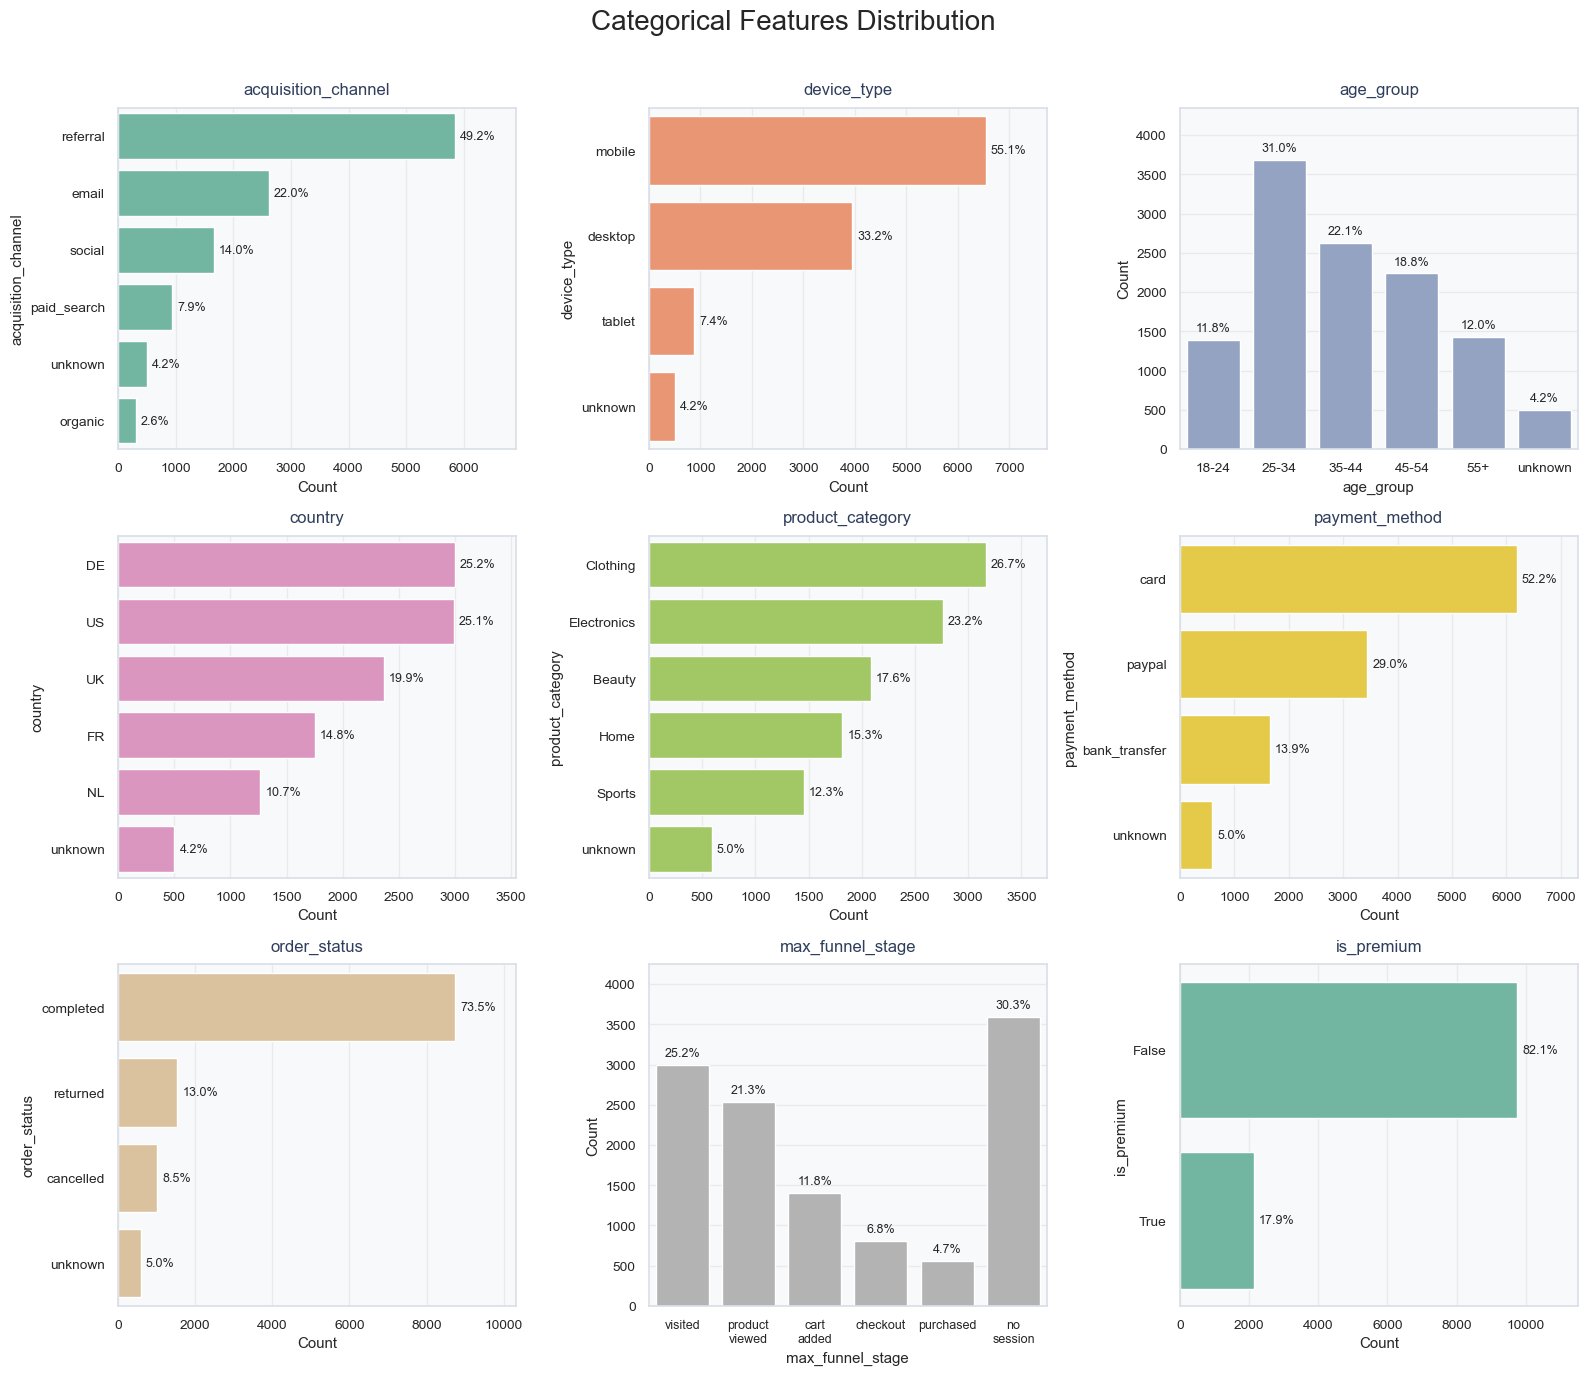

In [172]:

import seaborn as sns
import matplotlib.pyplot as plt

ordered_cols = {"age_group", "max_funnel_stage"}

custom_orders = {
    "age_group": ["18-24", "25-34", "35-44", "45-54", "55+", "unknown"],
    "max_funnel_stage": ["visited", "product_viewed", "cart_added", "checkout", "purchased", "unknown"]
}

sns.set_theme(style="whitegrid", font_scale=0.9)
palette = sns.color_palette("Set2", len(cat_cols))

def get_counts(df, col, top_n=None):
    s = df[col].fillna("unknown").astype(str)
    counts = s.value_counts()

    if col in custom_orders:
        ordered = [x for x in custom_orders[col] if x in counts.index]
        remaining = [x for x in counts.index if x not in ordered]
        counts = counts.reindex(ordered + remaining)

    if col not in ordered_cols:
        counts = counts.sort_values(ascending=False)

    if top_n is not None:
        counts = counts.head(top_n)

    pct = (counts / counts.sum() * 100).round(1)
    return counts, pct

fig, axes = plt.subplots(3, 3, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ax = axes[i]
    color = palette[i]

    top_n = 10 if col == "country" else None
    counts, pct = get_counts(df, col, top_n=top_n)

    # prettier labels for funnel stages
    plot_labels = counts.index.to_series().copy()
    if col == "max_funnel_stage":
        plot_labels = plot_labels.str.replace("_", "\n", regex=False)

    # ordered columns -> vertical bars
    if col in ordered_cols:
        sns.barplot(
            x=plot_labels,
            y=counts.values,
            ax=ax,
            color=color
        )

        ax.set_xlabel(col)
        ax.set_ylabel("Count")
        ax.set_ylim(0, counts.max() * 1.18)

        for j, v in enumerate(counts.values):
            ax.text(j, v + counts.max() * 0.02, f"{pct.iloc[j]}%", ha="center", va="bottom", fontsize=9)

        if col == "max_funnel_stage":
            ax.tick_params(axis="x", rotation=0, labelsize=9)
        else:
            ax.tick_params(axis="x", rotation=0)

        ax.grid(axis="y", color="#EAEAEA")
        ax.grid(axis="x", visible=False)

    # other columns -> horizontal bars
    else:
        sns.barplot(
            y=counts.index,
            x=counts.values,
            ax=ax,
            color=color
        )

        ax.set_xlabel("Count")
        ax.set_ylabel(col)
        ax.set_xlim(0, counts.max() * 1.18)

        for j, v in enumerate(counts.values):
            ax.text(v + counts.max() * 0.015, j, f"{pct.iloc[j]}%", va="center", fontsize=9)

        ax.grid(axis="x", color="#EAEAEA")
        ax.grid(axis="y", visible=False)

    # panel styling
    ax.set_title(col, fontsize=12, pad=10, color="#2F3E5C")
    ax.set_facecolor("#F8F9FB")
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("#D9DEE7")
        spine.set_linewidth(1.2)

fig.suptitle("Categorical Features Distribution", fontsize=20, y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

### Categorical Features  Univariate Analysis — Key Findings

**9 categorical features** across acquisition, demographics, behaviour, and transactions.

### Acquisition_channel  & Device_type

- **Referral dominates** acquisition (49.2%), followed by email (22%) and social (14%) — paid channels (search + organic) account for only ~10.5%.
- **Mobile-first audience**: 55.1% mobile, 33.2% desktop — responsive/mobile UX is critical.

###  Demographics & Geography

- Core age bracket is **25–34 (31%)**, with a healthy 35–44 (22.1%) segment; under-24s and 55+ are the smallest groups.
- Geography is fairly balanced: **DE (25.2%) ≈ US (25.1%)**, followed by UK (19.9%), FR (14.8%), NL (10.7%).

###  Product & Payment

- **Clothing leads** product mix (28.7%), with Electronics (23.2%) and Beauty (17.6%) as strong secondary categories.
- **Card is the dominant payment method** (52.2%), with PayPal at 29% — bank transfer is a distant third (13.9%).

###  Funnel & Order Health

- **30.3% of users had no session recorded** — a data quality flag or significant drop-off before any engagement.
- Of users with sessions, most reach only "visited" (25.2%) or "product viewed" (21.3%); only **4.7% reached "purchased"** — steep funnel drop-off.
- **73.5% of orders completed**, but 13% returned and 8.5% cancelled — combined leakage of ~21.5% warrants investigation.
- **Premium users are a minority at 17.9%** — potential growth lever for loyalty/upsell strategies.


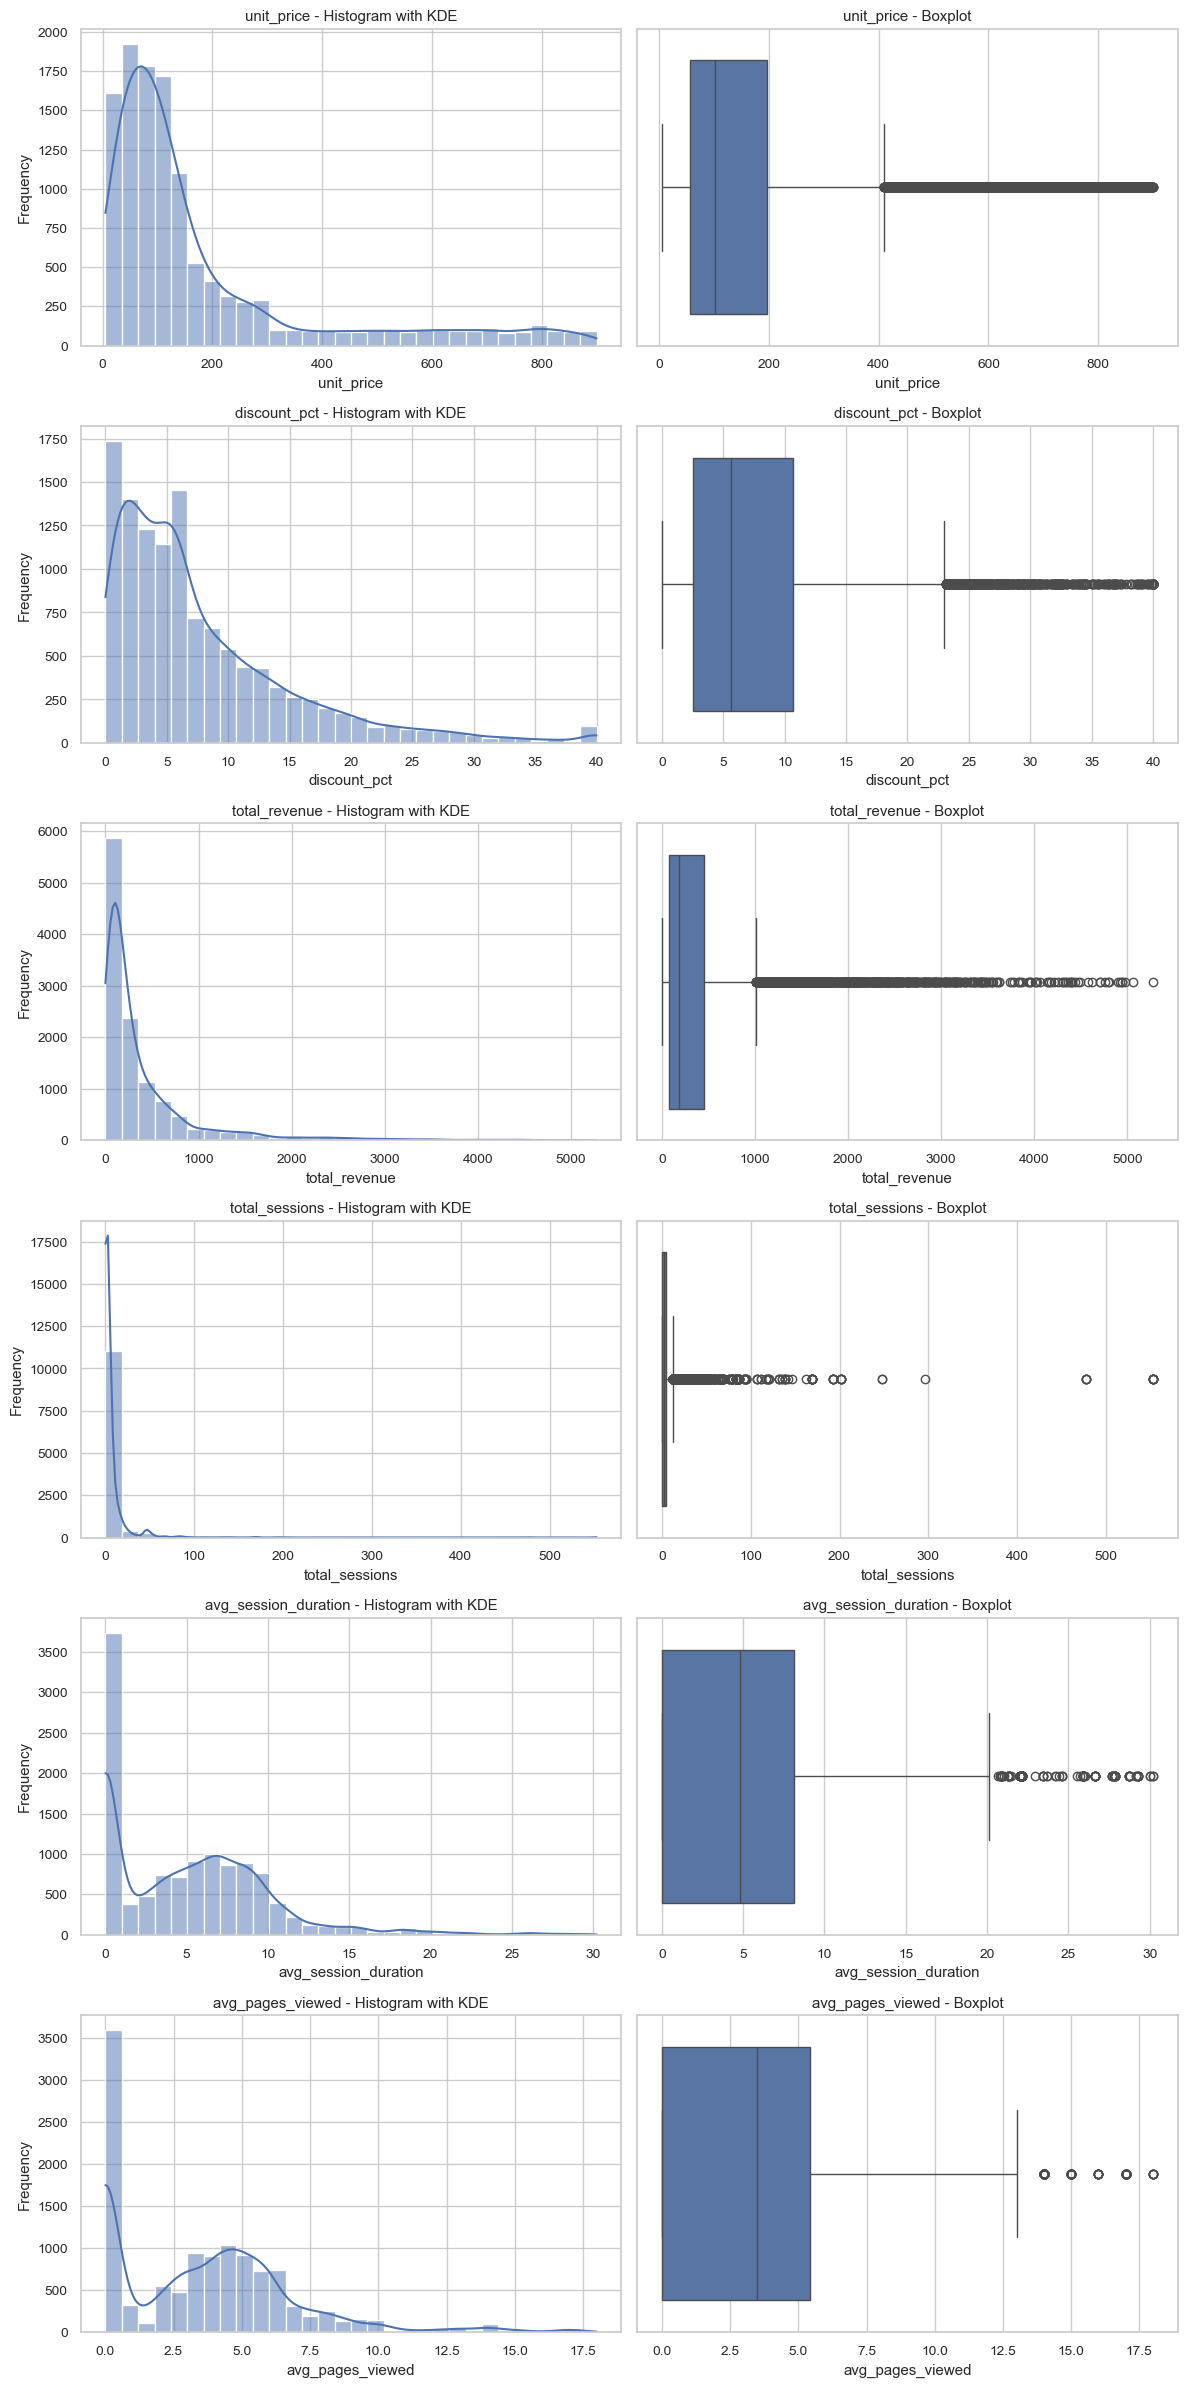

In [173]:
import math
import seaborn as sns
import matplotlib.pyplot as plt

# numerical columns
num_cols =[
    "unit_price",
    "discount_pct",
    "total_revenue",
    "total_sessions",
    "avg_session_duration",
    "avg_pages_viewed"
]

sns.set_theme(style="whitegrid", font_scale=0.9)

n = len(num_cols)
fig, axes = plt.subplots(n, 2, figsize=(12, 4 * n))

if n == 1:
    axes = [axes]

for i, col in enumerate(num_cols):
    # Histogram + KDE
    sns.histplot(df[col].dropna(), bins=30, kde=True, ax=axes[i][0])
    axes[i][0].set_title(f"{col} - Histogram with KDE")
    axes[i][0].set_xlabel(col)
    axes[i][0].set_ylabel("Frequency")

    # Boxplot
    sns.boxplot(x=df[col].dropna(), ax=axes[i][1])
    axes[i][1].set_title(f"{col} - Boxplot")
    axes[i][1].set_xlabel(col)

plt.tight_layout()
plt.show()

### Univariate Distribution Analysis Findingsand Understanding Outliers 

All 6 numeric features show **right-skewed distributions** with varying outlier severity.

### Distribution Shape & Outliers

| Feature | Shape | Outlier Range | Likely Cause |
|---|---|---|---|
| `unit_price` | Right-skewed, peak ~50–100 | Up to ~900 | Premium product tier — plausible |
| `discount_pct` | Right-skewed, peak ~0–5% | Tail to 40% | Promotional campaigns — plausible |
| `total_revenue` | Severely right-skewed | Dense cloud beyond ~1,500 | Bulk/B2B orders — plausible |
| `total_sessions` | Extremely skewed, mostly 0–50 | Isolated points 300–550 | Power users or bots — needs review |
| `avg_session_duration` | Bimodal (0–2 and ~6–8 min) | Tail to 30 min | Engaged users — plausible |
| `avg_pages_viewed` | Bimodal, mirrors duration | Few points ~13–18 | Consistent with long sessions |

### Boxplot Interpretation & Outlier Assessment

Not all statistical outliers are data errors — context matters for each feature:

- **`total_revenue`**: Boxplot shows a compressed IQR (≈€77–€450) with a 
  dense outlier cloud stretching to €5,277. These are **likely legitimate** — 
  a customer ordering 6 units of a €900 item naturally produces high revenue. 
  No data error suspected; reflects real purchasing behaviour variation.

- **`unit_price`**: IQR sits ~€55–€197 with a tail to ~€900. Given the 
  catalogue spans Clothing to Electronics, **high-end SKUs are expected** 
  and these points are commercially plausible.

- **`discount_pct`**: Wide IQR with outliers at 25–40%. These likely 
  correspond to **flash sales or clearance events** — not errors, but worth 
  tagging if discount type metadata is available.

- **`total_sessions`**: The most suspicious feature — isolated points at 
  300–550 sessions are **disproportionately high** compared to the bulk of 
  users (median = 2). Could represent loyalty power users, but also warrants 
  a check for **tracking duplicates or bot traffic**.

- **`avg_session_duration` & `avg_pages_viewed`**: Outliers are mild and 
  **consistent with engaged user behaviour**. No data quality concern.

### Overall Assessment

> The majority of outliers across this dataset reflect **natural business 
> variation** (premium products, bulk orders, promotions) rather than data 
> errors. The only feature requiring deeper validation is `total_sessions`, 
> where extreme values may indicate tracking anomalies.


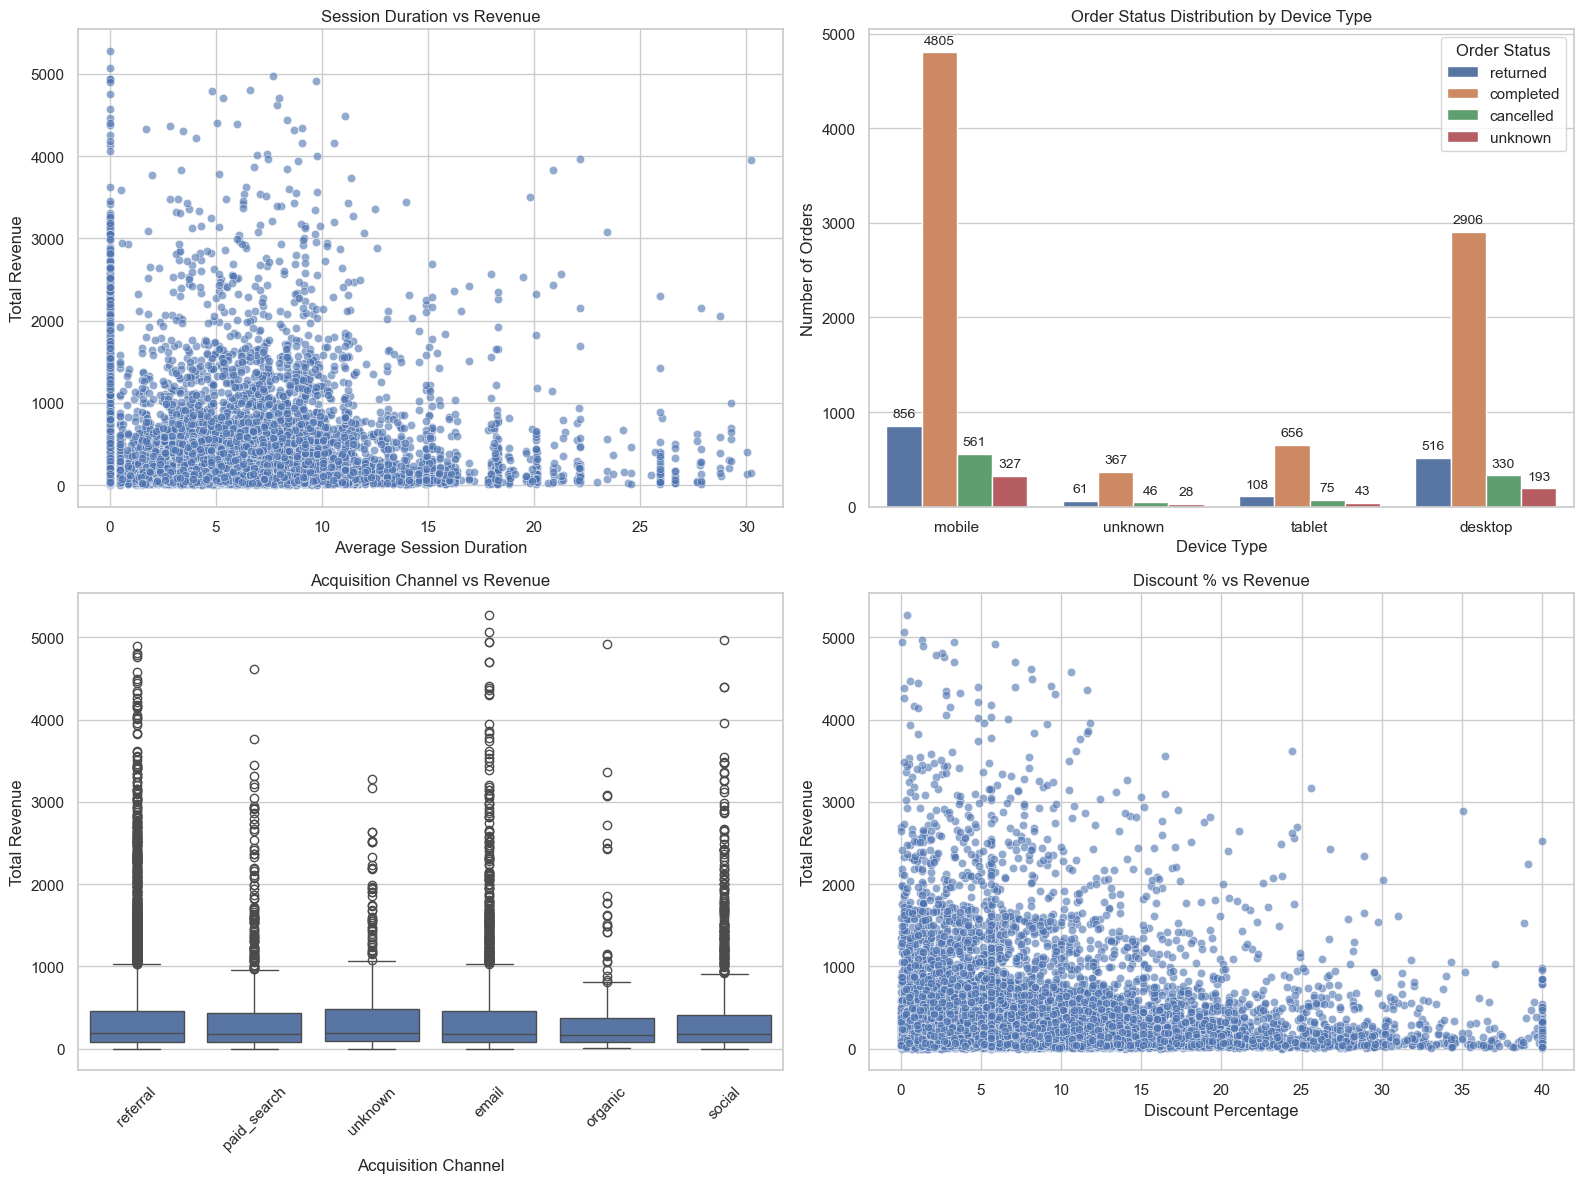

In [174]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid", palette="deep")

# Conversion flag
df["is_converted"] = df["order_status"].apply(lambda x: 1 if str(x).lower() == "completed" else 0)

# Create 2x2 subplot layout
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Session Duration vs Revenue
sns.scatterplot(
    data=df,
    x="avg_session_duration",
    y="total_revenue",
    alpha=0.6,
    ax=axes[0, 0]
)
axes[0, 0].set_title("Session Duration vs Revenue")
axes[0, 0].set_xlabel("Average Session Duration")
axes[0, 0].set_ylabel("Total Revenue")


# 2. Device Type vs Order Status Distribution (Volume)

ax_count = sns.countplot(
    data=df,
    x="device_type",
    hue="order_status",
    ax=axes[0,1]
)

axes[0,1].set_title("Order Status Distribution by Device Type")
axes[0,1].set_xlabel("Device Type")
axes[0,1].set_ylabel("Number of Orders")

# Add count labels on bars
for p in ax_count.patches:
    height = p.get_height()
    if height > 0:
        ax_count.annotate(
            f'{int(height)}',
            (p.get_x() + p.get_width()/2, height),
            ha='center',
            va='bottom',
            fontsize=10,
            xytext=(0,4),
            textcoords='offset points'
        )

axes[0,1].legend(title="Order Status")


# 3. Acquisition Channel vs Revenue
sns.boxplot(
    data=df,
    x="acquisition_channel",
    y="total_revenue",
    ax=axes[1, 0]
)
axes[1, 0].set_title("Acquisition Channel vs Revenue")
axes[1, 0].set_xlabel("Acquisition Channel")
axes[1, 0].set_ylabel("Total Revenue")
axes[1, 0].tick_params(axis="x", rotation=45)


# 4. Discount % vs Revenue
sns.scatterplot(
    data=df,
    x="discount_pct",
    y="total_revenue",
    alpha=0.6,
    ax=axes[1, 1]
)
axes[1, 1].set_title("Discount % vs Revenue")
axes[1, 1].set_xlabel("Discount Percentage")
axes[1, 1].set_ylabel("Total Revenue")

plt.tight_layout()
plt.show()

#### Bivariate Analysis — Key Findings

### Session Duration vs Revenue
No meaningful relationship — high-revenue orders occur at **all session lengths**, 
including very short ones. Purchase value appears driven by product/quantity choice, 
not browsing time.

####  Device Type vs Order Status
Mobile leads in completed order volume (4,805) but carries a **higher return rate 
(~17.8%)** vs desktop (~11.4%). Desktop buyers show more purchase intent despite 
lower traffic share.

####  Acquisition Channel vs Revenue
All channels have near-identical IQR — **channel does not differentiate order value**. 
Email and referral occasionally produce high-value outliers (>€4,000); organic 
consistently yields the smallest orders.

#### Discount % vs Revenue
Clear inverse pattern — **high-revenue orders cluster at 0–5% discount**. Deep 
discounts (>15%) appear only on low-value transactions. Discounting is not a 
revenue driver in this dataset.

 **Key takeaway:** No single variable strongly predicts revenue. The strongest  signals are that **premium orders need no discount**, and **desktop users  convert with fewer returns**.


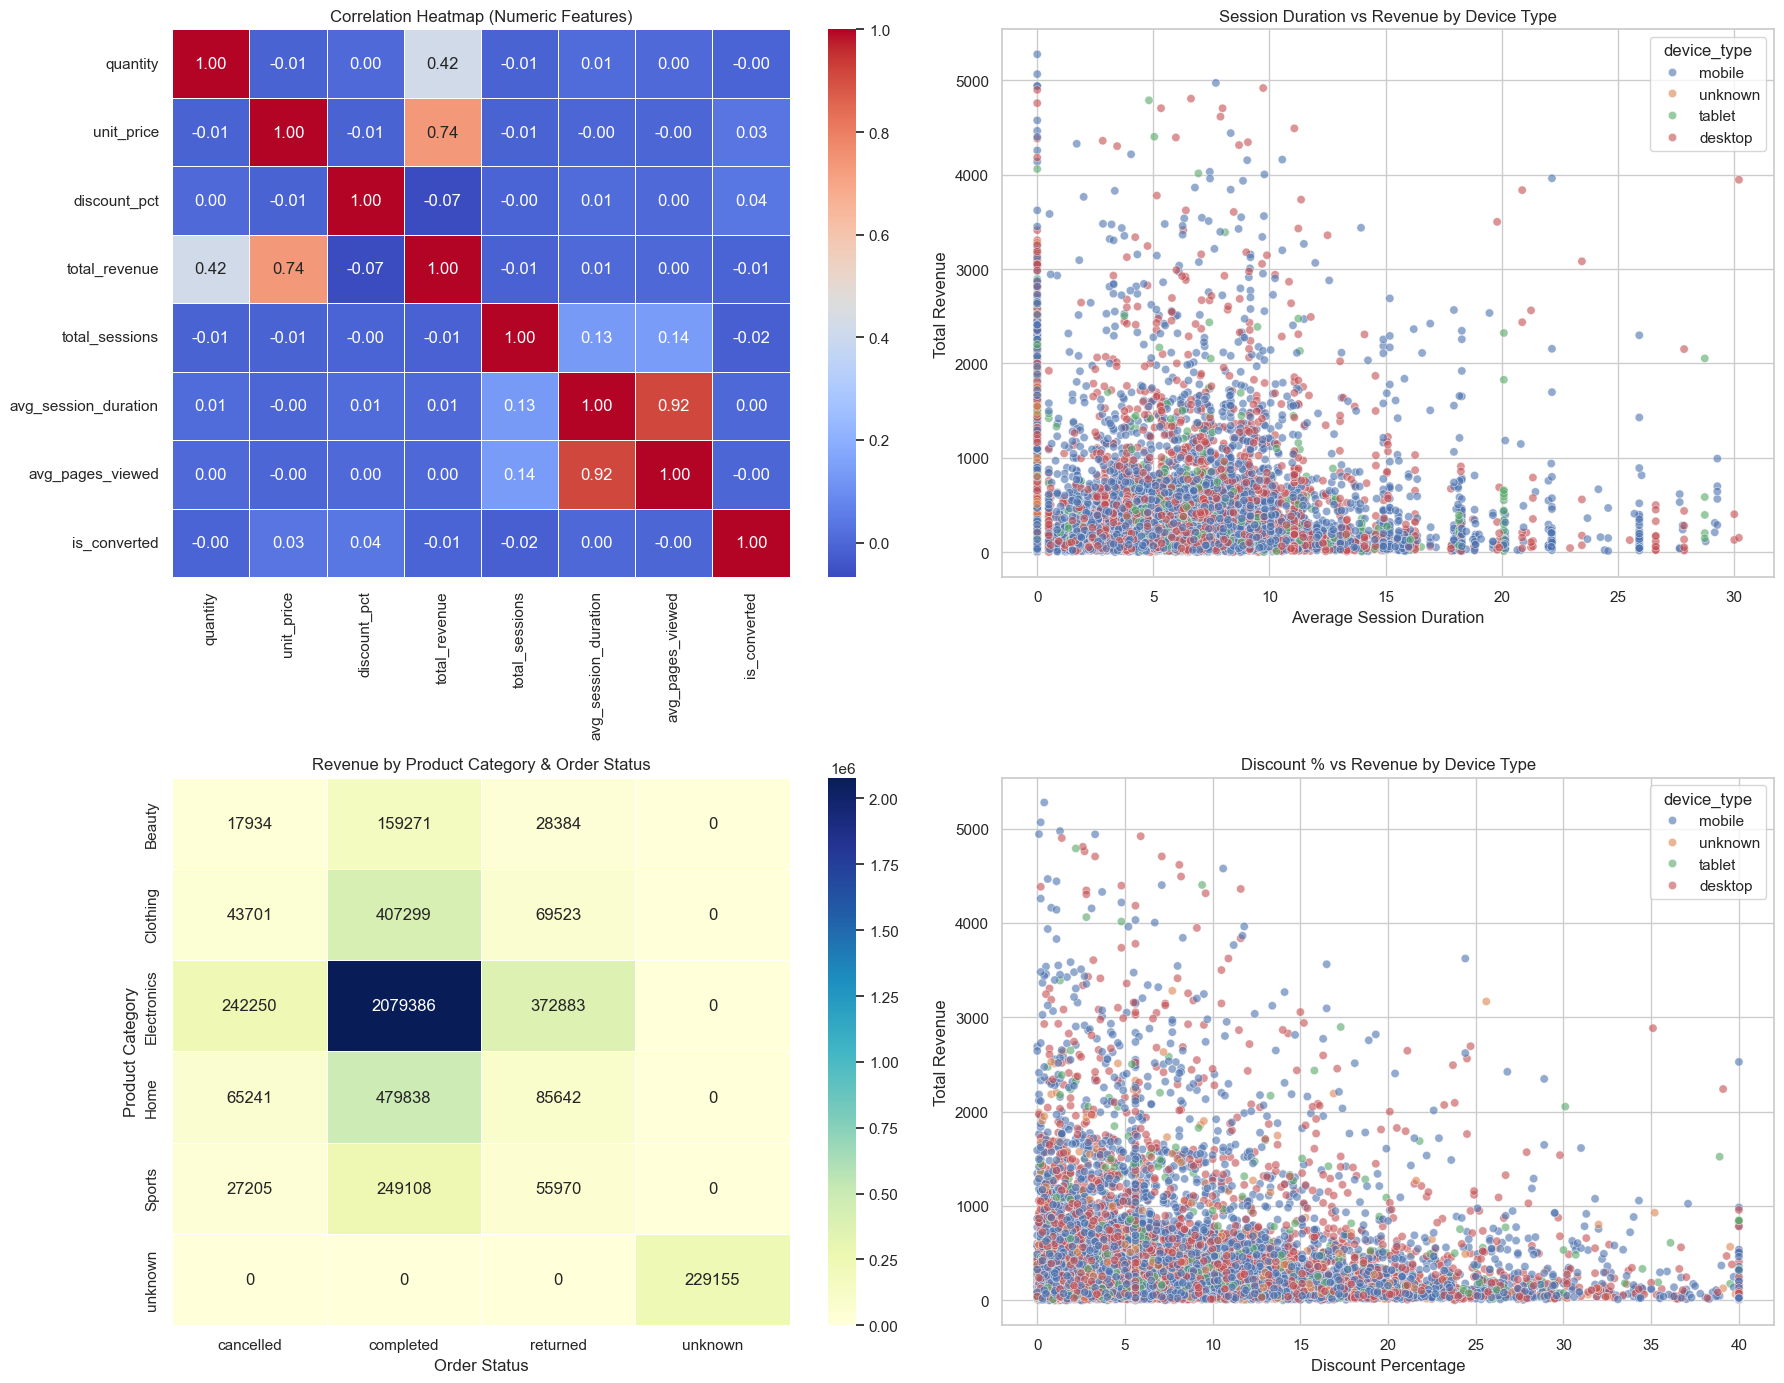

In [175]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid", palette="deep")

# Select numeric columns
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns

# Optional: remove ID-like columns from correlation/pairplot
numeric_cols = [col for col in numeric_cols if col not in ["order_id", "customer_id"]]

# Create 2x2 subplot layout
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# 5.2.1 Correlation Heatmap (all numerics)
corr_matrix = df[numeric_cols].corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    ax=axes[0, 0]
)
axes[0, 0].set_title("Correlation Heatmap (Numeric Features)")


# 5.2.2 Session Duration vs Revenue by Device Type
sns.scatterplot(
    data=df,
    x="avg_session_duration",
    y="total_revenue",
    hue="device_type",
    alpha=0.6,
    ax=axes[0, 1]
)
axes[0, 1].set_title("Session Duration vs Revenue by Device Type")
axes[0, 1].set_xlabel("Average Session Duration")
axes[0, 1].set_ylabel("Total Revenue")


# 5.2.3 Revenue by Product Category & Order Status (Pivot Heatmap)
pivot_table = pd.pivot_table(
    df,
    values="total_revenue",
    index="product_category",
    columns="order_status",
    aggfunc="sum",
    fill_value=0
)

sns.heatmap(
    pivot_table,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu",
    linewidths=0.5,
    ax=axes[1, 0]
)
axes[1, 0].set_title("Revenue by Product Category & Order Status")
axes[1, 0].set_xlabel("Order Status")
axes[1, 0].set_ylabel("Product Category")


# 5.2.4 Discount % vs Revenue by Device Type
sns.scatterplot(
    data=df,
    x="discount_pct",
    y="total_revenue",
    hue="device_type",
    alpha=0.6,
    ax=axes[1, 1]
)
axes[1, 1].set_title("Discount % vs Revenue by Device Type")
axes[1, 1].set_xlabel("Discount Percentage")
axes[1, 1].set_ylabel("Total Revenue")

plt.tight_layout()
plt.show()

## 7. Multivariate Analysis — Key Findings

### 7.1 Correlation Heatmap

| Pair | Correlation | Interpretation |
|---|---|---|
| `unit_price` ↔ `total_revenue` | **0.74** | Strong — price is the primary revenue driver |
| `quantity` ↔ `total_revenue` | **0.42** | Moderate — volume contributes but less than price |
| `avg_session_duration` ↔ `avg_pages_viewed` | **0.92** | Near-perfect — these two move together, likely redundant |
| `total_sessions` ↔ `avg_session_duration` | **0.13** | Weak — more sessions ≠ longer sessions |
| `discount_pct` ↔ `total_revenue` | **-0.07** | Negligible — confirms discounts don't drive revenue |
| All others | ~0.00 | No meaningful relationships |

> **`avg_session_duration` and `avg_pages_viewed` are highly collinear (0.92)** — 
> only one should be used in any downstream analysis.

---

### 7.2 Session Duration vs Revenue by Device Type

No device type shows a distinct revenue pattern across session durations — 
**all four devices overlap uniformly**. High-revenue orders appear at short 
sessions across mobile, desktop, and tablet equally. Device type does not 
interact with session duration to influence revenue.

---

### 7.3 Revenue by Product Category & Order Status

- **Electronics dominates completed revenue (€2.08M)** — nearly 4× Clothing 
  (€407K) and 4× Home (€480K), despite not being the highest order-count category.
- **Return revenue is proportionally high in Electronics (€373K ≈ 18% of completed)** 
  vs Clothing (€70K ≈ 17%) — return rates are consistent across categories.
- **No cancellations recorded for unknown category** — all €229K sits in 
  "unknown" order status, flagging a **data quality issue** worth investigating.

---

### 7.4 Discount % vs Revenue by Device Type

Consistent with bivariate findings — the inverse discount-revenue pattern holds 
**across all device types with no meaningful difference**. Device type does not 
moderate the discount-revenue relationship.

---

> **Key takeaway:** `unit_price` is the strongest revenue driver (r=0.74). 
> Electronics is the highest-value category but also the highest return risk. 
> Session behaviour metrics have no material impact on revenue regardless of device.


#### Feature Engineering

In [176]:
#Creating Features

sns.set(style="whitegrid", palette="deep")

# Revenue per session
# Avoid division by zero when total_sessions = 0
df["revenue_per_session"] = df["total_revenue"] / df["total_sessions"].replace(0, pd.NA)

# Conversion flag
# Best practical choice for your dataset:
# 1 if order was completed, else 0
df["conversion_flag"] = df["order_status"].astype(str).str.lower().eq("completed").astype(int)

# Day of week from order_date
df["day_of_week"] = pd.to_datetime(df["order_date"]).dt.day_name()

# Customer lifetime orders
df["customer_lifetime_orders"] = df.groupby("customer_id")["order_id"].transform("count")

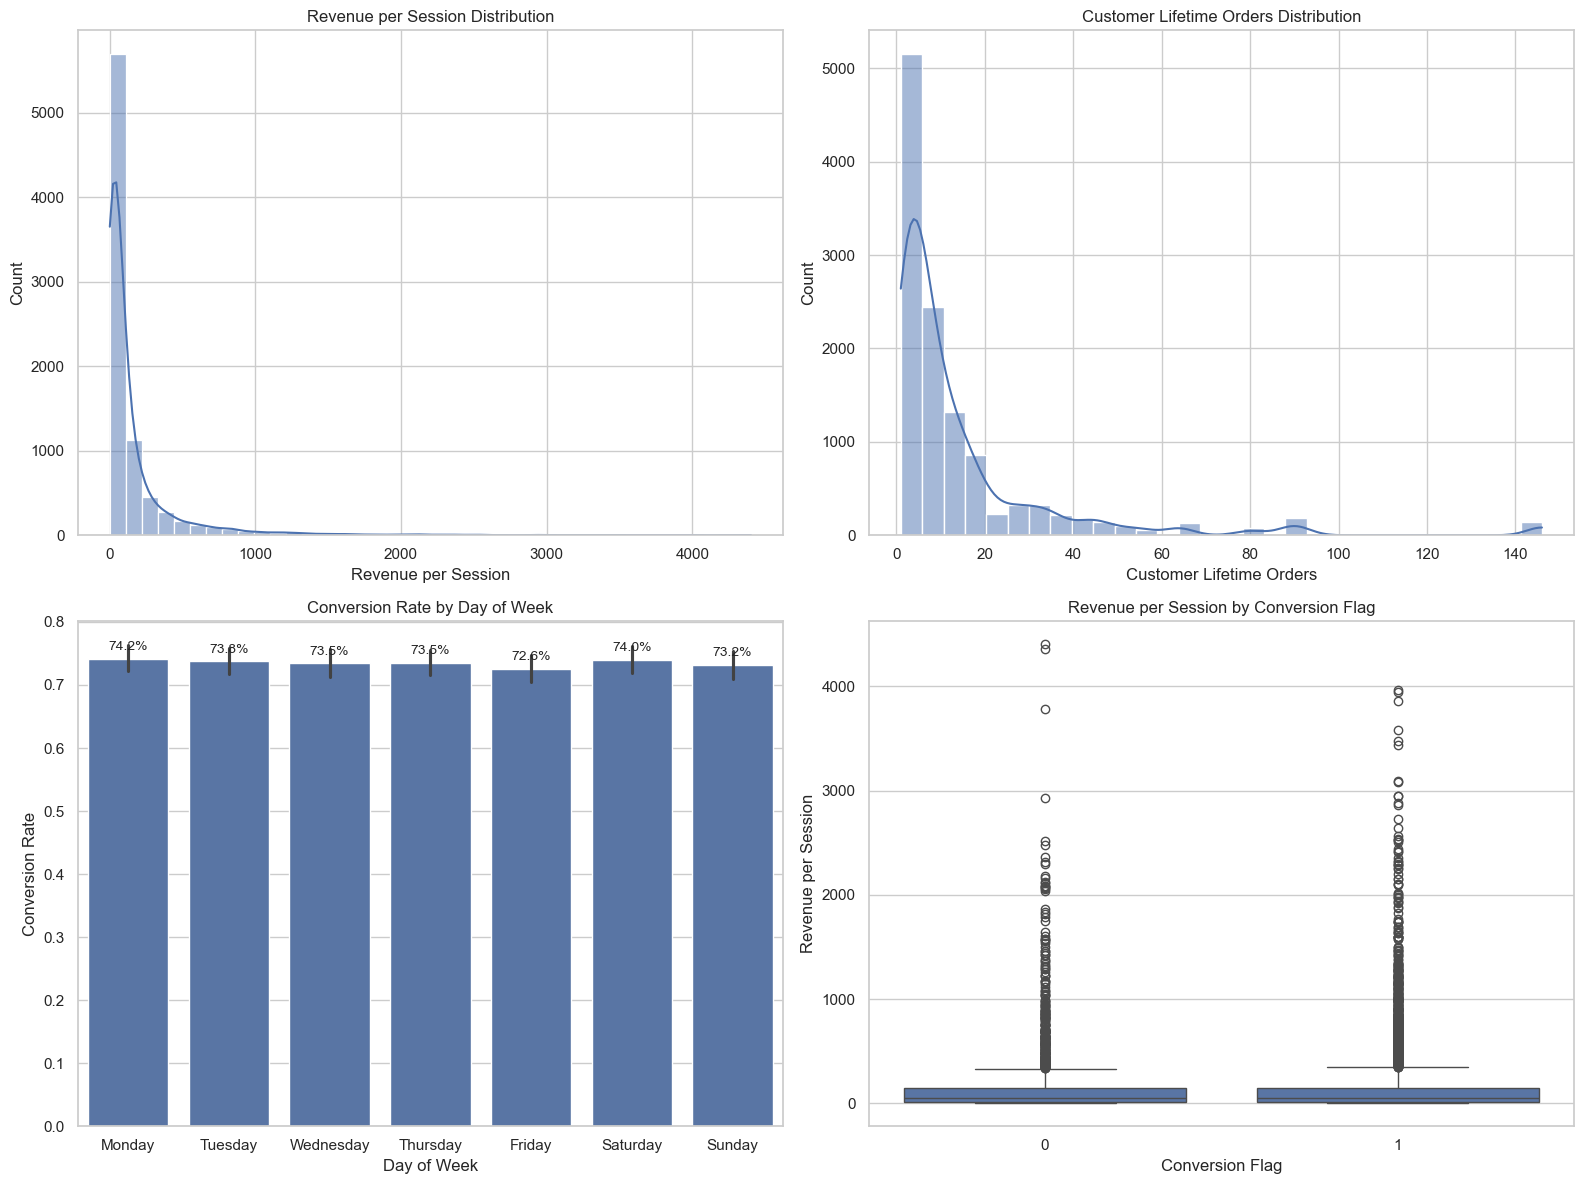

In [177]:
#New Feature Distributions
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Revenue per session distribution
sns.histplot(
    data=df,
    x="revenue_per_session",
    bins=40,
    kde=True,
    ax=axes[0, 0]
)
axes[0, 0].set_title("Revenue per Session Distribution")
axes[0, 0].set_xlabel("Revenue per Session")
axes[0, 0].set_ylabel("Count")

# 2. Customer lifetime orders distribution
sns.histplot(
    data=df,
    x="customer_lifetime_orders",
    bins=30,
    kde=True,
    ax=axes[0, 1]
)
axes[0, 1].set_title("Customer Lifetime Orders Distribution")
axes[0, 1].set_xlabel("Customer Lifetime Orders")
axes[0, 1].set_ylabel("Count")

# 3. Conversion rate by day of week
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

ax_bar = sns.barplot(
    data=df,
    x="day_of_week",
    y="conversion_flag",
    order=day_order,
    estimator="mean",
    ax=axes[1, 0]
)

axes[1, 0].set_title("Conversion Rate by Day of Week")
axes[1, 0].set_xlabel("Day of Week")
axes[1, 0].set_ylabel("Conversion Rate")

# Add labels as percentages
for p in ax_bar.patches:
    height = p.get_height()
    if pd.notna(height):
        ax_bar.annotate(
            f"{height*100:.1f}%",
            (p.get_x() + p.get_width() / 2, height),
            ha="center",
            va="bottom",
            fontsize=10,
            xytext=(0, 4),
            textcoords="offset points"
        )

# 4. Revenue per session by conversion flag
sns.boxplot(
    data=df,
    x="conversion_flag",
    y="revenue_per_session",
    ax=axes[1, 1]
)
axes[1, 1].set_title("Revenue per Session by Conversion Flag")
axes[1, 1].set_xlabel("Conversion Flag")
axes[1, 1].set_ylabel("Revenue per Session")

plt.tight_layout()
plt.show()

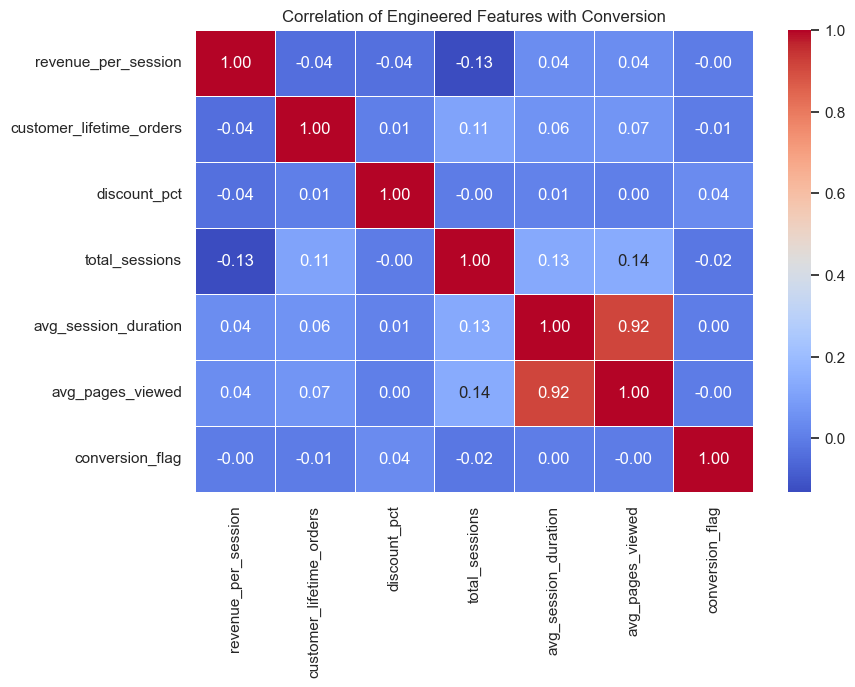

In [178]:
import numpy as np

# Revenue per session
df["revenue_per_session"] = np.where(
    df["total_sessions"] > 0,
    df["total_revenue"] / df["total_sessions"],
    np.nan
)

# Conversion flag
df["conversion_flag"] = df["order_status"].astype(str).str.lower().eq("completed").astype(int)

# Day of week
df["day_of_week"] = pd.to_datetime(df["order_date"]).dt.day_name()

# Customer lifetime orders
df["customer_lifetime_orders"] = df.groupby("customer_id")["order_id"].transform("count")

# Correlation
feature_cols = [
    "revenue_per_session",
    "customer_lifetime_orders",
    "discount_pct",
    "total_sessions",
    "avg_session_duration",
    "avg_pages_viewed",
    "conversion_flag"
]

corr_df = df[feature_cols].apply(pd.to_numeric, errors="coerce")

plt.figure(figsize=(9, 6))
sns.heatmap(
    corr_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)
plt.title("Correlation of Engineered Features with Conversion")
plt.show()

#### Feature Engineering — Key Findings

Four new features were engineered to enrich the dataset beyond raw transactional fields.

#### `revenue_per_session`
Heavily right-skewed — the vast majority of customers generate **<€200 per session**, 
with a long tail to ~€4,500. Mirrors `total_revenue` distribution, confirming most 
customers are low-efficiency browsers. The few high-value points represent 
customers who converted quickly with high-value orders.

####  `customer_lifetime_orders`
Right-skewed with most customers holding **1–5 lifetime orders**. The tail extends 
to ~140 orders, indicating a small loyal repeat-buyer segment. The sharp drop-off 
after ~10 orders confirms the majority of the customer base is **transactional 
rather than loyal**.

####  `day_of_week`
Conversion rate is **remarkably flat across all days (72.6%–74.2%)** — Monday 
marginally highest, Friday lowest. The <2% spread means **day of week has no 
meaningful influence on conversion**. No weekend effect observed.

#### `conversion_flag` vs `revenue_per_session`
Both converted (1) and non-converted (0) groups share a **near-identical IQR and 
outlier structure** — conversion flag alone is a weak signal for revenue quality.

#### Engineered Features Correlation Heatmap

| Pair | Correlation | Interpretation |
|---|---|---|
| `avg_session_duration` ↔ `avg_pages_viewed` | **0.92** | Confirmed collinearity — drop one |
| `total_sessions` ↔ `avg_pages_viewed` | **0.14** | Weak but the strongest session-behaviour link |
| `total_sessions` ↔ `avg_session_duration` | **0.13** | Weak — session count ≠ session quality |
| `revenue_per_session` ↔ `total_sessions` | **-0.13** | Slight inverse — more sessions = lower rev/session |
| `conversion_flag` ↔ all features | **~0.00** | Conversion is effectively uncorrelated with all engineered features |
| All others | ~0.00 | No meaningful relationships |

> **Critical finding:** `conversion_flag` shows **zero correlation with every 
> engineered feature** — it cannot be predicted from session behaviour, discount, 
> or lifetime order metrics alone. This suggests conversion is driven by factors 
> not captured in this dataset (e.g. product affinity, pricing intent).

---

> **Engineering verdict:** `customer_lifetime_orders` is the most informative 
> new feature — it surfaces a loyal repeat-buyer segment invisible in single-order 
> views. `day_of_week` adds no analytical value and can be deprioritised.


### Hypothesis Tests

H1 — Higher Session Duration → Higher Revenue
Test: Pearson Correlation

In [179]:
from scipy.stats import pearsonr
corr, p_value = pearsonr(
    df["avg_session_duration"],
    df["total_revenue"]
)

print("Pearson Correlation:", round(corr,3))
print("P-value:", p_value)

Pearson Correlation: 0.007
P-value: 0.44278229808380715


### H1 — Relationship Between Session Duration and Revenue 

**Hypothesis**

H1: Higher session duration leads to higher revenue.

**Method**

To evaluate this hypothesis, the **Pearson correlation coefficient** was computed between:

- `avg_session_duration`
- `total_revenue`

Pearson correlation measures the **strength and direction of a linear relationship** between two continuous variables.

**Results**

| Metric | Value |
|------|------|
| Pearson Correlation (r) | 0.007 |
| p-value | 0.443 |

**Interpretation**

The correlation coefficient (r = 0.007) indicates **no meaningful linear relationship** between session duration and revenue.  
Additionally, the **p-value (0.443) is greater than the significance threshold of 0.05**, indicating that the observed relationship is **not statistically significant**.

**Conclusion**

The analysis provides **no evidence to support H1**. In this dataset, longer session durations do not appear to be associated with higher revenue.


#### H2 — 20% Customers Generate 80% Revenue (Pareto)

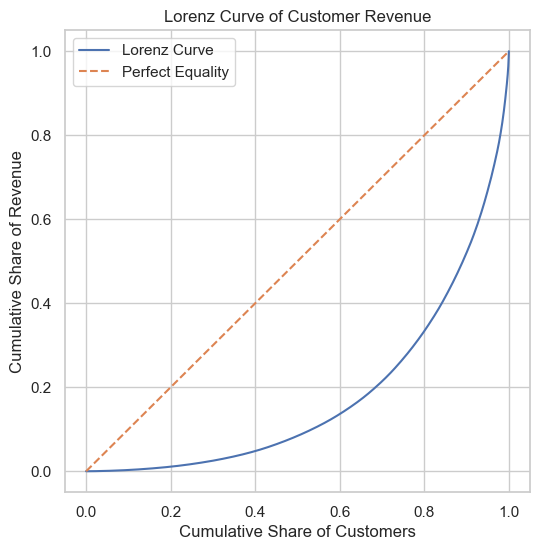

Gini Coefficient: 0.643


In [180]:
customer_revenue = (
    df.groupby("customer_id")["total_revenue"]
    .sum()
    .sort_values()
)

cum_customers = np.linspace(0,1,len(customer_revenue))
cum_revenue = np.cumsum(customer_revenue) / customer_revenue.sum()

plt.figure(figsize=(6,6))

plt.plot(cum_customers, cum_revenue, label="Lorenz Curve")
plt.plot([0,1],[0,1], linestyle="--", label="Perfect Equality")

plt.title("Lorenz Curve of Customer Revenue")
plt.xlabel("Cumulative Share of Customers")
plt.ylabel("Cumulative Share of Revenue")
plt.legend()

plt.show()


def gini(x):
    x = np.sort(x)
    n = len(x)
    cumulative = np.cumsum(x)
    gini_index = (n + 1 - 2 * np.sum(cumulative) / cumulative[-1]) / n
    return gini_index

gini_coeff = gini(customer_revenue.values)

print("Gini Coefficient:", round(gini_coeff,3))

 ### H2 — Do 20% of Customers Generate 80% of Revenue? (Pareto Principle)

**Hypothesis**

H2: A small share of customers (approximately 20%) generates the majority of revenue (approximately 80%), consistent with the **Pareto Principle**.

**Method**

To evaluate this hypothesis, customer revenue concentration was analyzed using:

- **Lorenz Curve** — visualizes the cumulative distribution of revenue across customers.
- **Gini Coefficient** — quantifies the degree of inequality in revenue distribution.

Steps performed:
1. Total revenue was aggregated for each `customer_id`.
2. Customers were sorted from lowest to highest revenue.
3. The cumulative share of customers was plotted against the cumulative share of revenue to construct the **Lorenz Curve**.
4. The **Gini coefficient** was computed to quantify inequality.

**Results**

| Metric | Value |
|------|------|
| Gini Coefficient | 0.643 |

**Interpretation**

The **Lorenz Curve deviates substantially from the line of perfect equality**, indicating that revenue is highly concentrated among a subset of customers.

The **Gini coefficient of 0.643** indicates **strong inequality in revenue distribution**. Values closer to 1 represent higher concentration, meaning that a relatively small group of customers contributes disproportionately to total revenue.

**Conclusion**

The results provide **strong support for H2**. Revenue in this dataset is highly concentrated among a limited subset of customers, consistent with **Pareto-like behavior**, where a minority of customers generate a majority of revenue.

**Business Insight**

This finding suggests that **high-value customers play a critical role in revenue generation**. Businesses may benefit from:

- targeted retention strategies for high-value customers
- loyalty or VIP programs
- personalized marketing campaigns

Focusing on this segment could significantly improve revenue stability and long-term customer value.

#### H3 — Weekends Have Higher Average Order Value

Test: Mann–Whitney U Test

Non-parametric test (good for revenue data).

Mann-Whitney U Statistic: 13978308.5
P-value: 0.17404183991906974


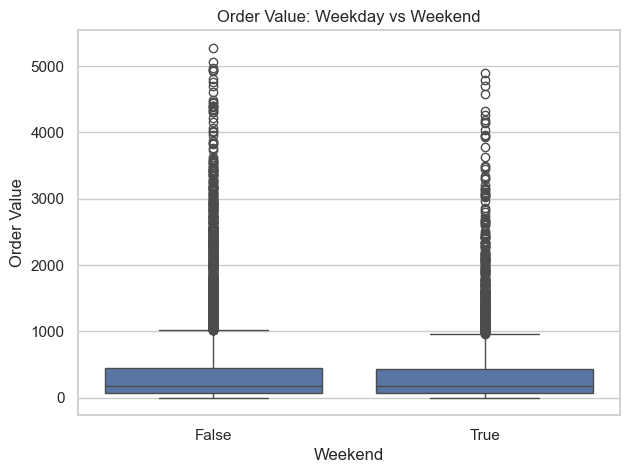

In [181]:
from scipy.stats import mannwhitneyu

df["order_date"] = pd.to_datetime(df["order_date"])

df["is_weekend"] = df["order_date"].dt.dayofweek >= 5

weekend_revenue = df[df["is_weekend"]]["total_revenue"]
weekday_revenue = df[~df["is_weekend"]]["total_revenue"]

stat, p_value = mannwhitneyu(
    weekend_revenue,
    weekday_revenue,
    alternative="two-sided"
)

print("Mann-Whitney U Statistic:", stat)
print("P-value:", p_value)

plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x="is_weekend",
    y="total_revenue"
)

plt.title("Order Value: Weekday vs Weekend")
plt.xlabel("Weekend")
plt.ylabel("Order Value")

plt.show()

### H3 — Do Weekends Have Higher Average Order Value?

**Hypothesis**

H3: Orders placed on weekends have higher average order value than those placed on weekdays.

**Method**

To test this hypothesis, a **Mann–Whitney U test** was applied to compare the distribution of `total_revenue` between:

- **Weekend orders** (Saturday and Sunday)
- **Weekday orders** (Monday–Friday)

The Mann–Whitney U test is a **non-parametric statistical test** used to determine whether two independent samples come from different distributions. It is appropriate here because order values are highly skewed and contain many outliers.

**Results**

| Metric | Value |
|------|------|
| Mann–Whitney U Statistic | 13,978,308.5 |
| p-value | 0.174 |

**Interpretation**

The **p-value (0.174) is greater than the significance threshold of 0.05**, indicating that the difference in order value distributions between weekdays and weekends is **not statistically significant**.

Although the visualization suggests slightly higher values for some weekend orders, the statistical test indicates that this difference could be due to random variation.

**Conclusion**

The analysis **does not provide sufficient evidence to support H3**. In this dataset, weekend orders do not appear to have significantly higher order values than weekday orders.

**Business Insight**

This suggests that customer spending behavior is relatively consistent across the week. Marketing strategies or promotions may therefore not need to prioritize weekends specifically for increasing order value, and other drivers such as **discount levels, product categories, or customer purchase history** may have stronger influence on revenue.